##Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers

##Load CIFAR-10 Dataset



In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


##Class Labels

In [3]:
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

##Visualize Images

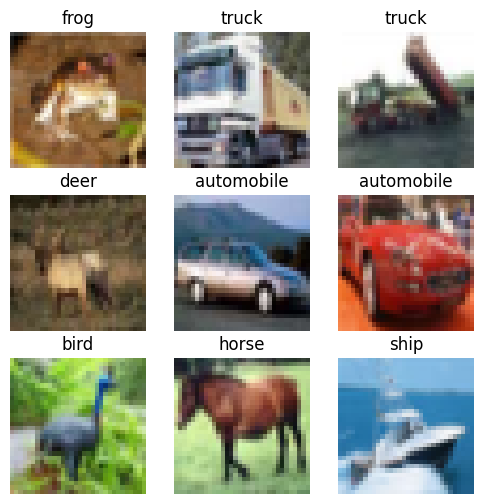

In [4]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.show()

##Data Preprocessing

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

##Build CNN Model

In [6]:
model = keras.Sequential([

    layers.Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


##Compile Model

In [7]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Train Model

In [8]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 61s 42ms/step - accuracy: 0.4388 - loss: 1.5375 - val_accuracy: 0.5580 - val_loss: 1.2488
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 58s 41ms/step - accuracy: 0.5914 - loss: 1.1520 - val_accuracy: 0.6292 - val_loss: 1.0417
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - accuracy: 0.6574 - loss: 0.9767 - val_accuracy: 0.6734 - val_loss: 0.9382
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - accuracy: 0.6952 - loss: 0.8690 - val_accuracy: 0.6610 - val_loss: 0.9679
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 60s 43ms/step - accuracy: 0.7243 - loss: 0.7821 - val_accuracy: 0.7056 - val_loss: 0.8538
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 79s 41ms/step - accuracy: 0.7518 - loss: 0.7059 - val_accuracy: 0.7062 - val_loss: 0.8578
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 83s 41ms/step - accuracy: 0.7741 - loss: 0.6435 - val_accuracy: 0.7166 - val_loss: 0.8508
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 82s 41ms/step - accuracy: 0.7924 -

##Evaluate Model

In [9]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7184 - loss: 0.8761
Test Accuracy: 0.7184000015258789


##Prediction Example

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step


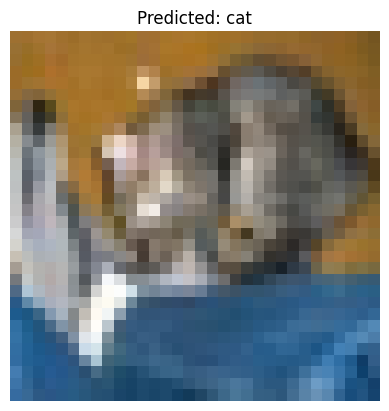

In [10]:
predictions = model.predict(x_test)

plt.imshow(x_test[0])
plt.title("Predicted: " + class_names[np.argmax(predictions[0])])
plt.axis("off")
plt.show()

##Plot Accuracy

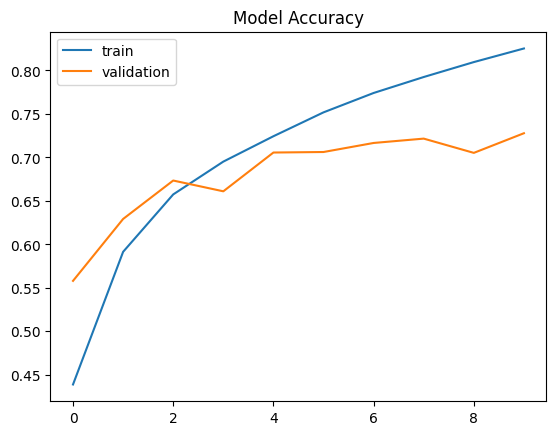

In [11]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['train','validation'])
plt.title("Model Accuracy")
plt.show()